## Conclusions

### Best Model
Random Forest — 79% accuracy (single split), 80.3% mean accuracy (5-fold cross validation)

### Key Findings
- Sex and Pclass are the strongest predictors of survival
- Feature engineering (FamilySize, IsAlone) did not significantly improve accuracy
- Cross validation gives a more reliable accuracy estimate than a single train/test split
- Random Forest

In [16]:
import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df=df.dropna(subset=['Age'])
df=df.drop(columns=['Cabin'])
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode)
print(df.shape)
print(df.head(2))
print(df.isna().sum())

(714, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   

   Parch     Ticket     Fare Embarked  
0      0  A/5 21171   7.2500        S  
1      0   PC 17599  71.2833        C  
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


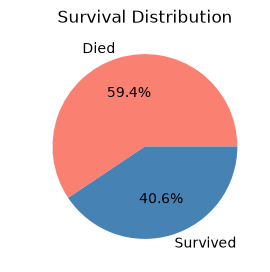

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
df['Survived'].value_counts().plot(kind='pie',
                                   labels=['Died','Survived'],
                                   colors=['salmon','steelblue'],
                                   autopct='%1.1f%%')
plt.title('Survival Distribution')
plt.ylabel(' ')
plt.show()

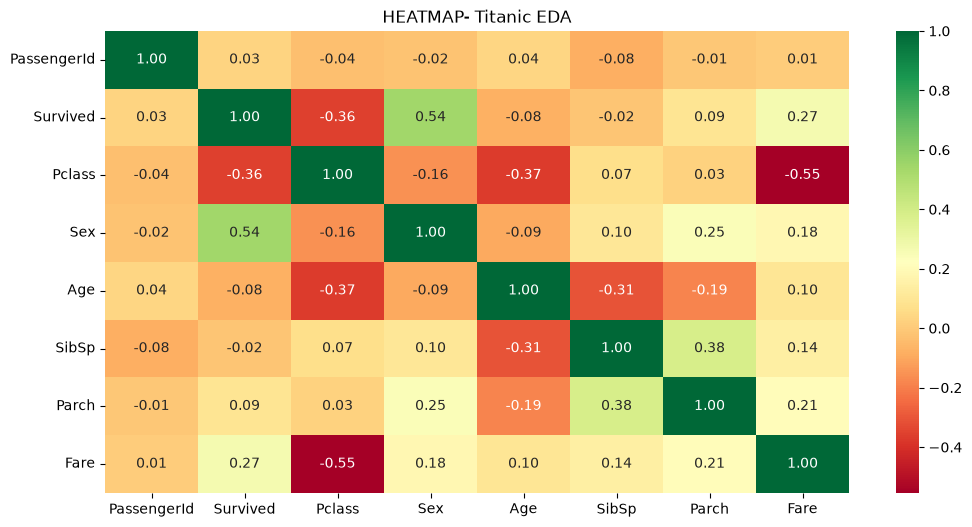

In [ ]:
import seaborn as sns 

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='RdYlGn')
plt.title('HEATMAP- Titanic EDA')
plt.show()



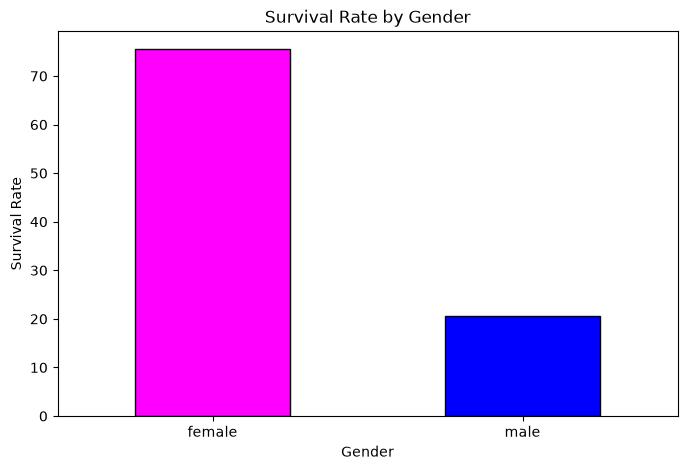

In [33]:
plt.figure(figsize=(8,5))
survival_rate_by_sex=df.groupby('Sex')['Survived'].mean()*100
survival_rate_by_sex.plot(kind='bar',color=['magenta','blue'],edgecolor='black')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()

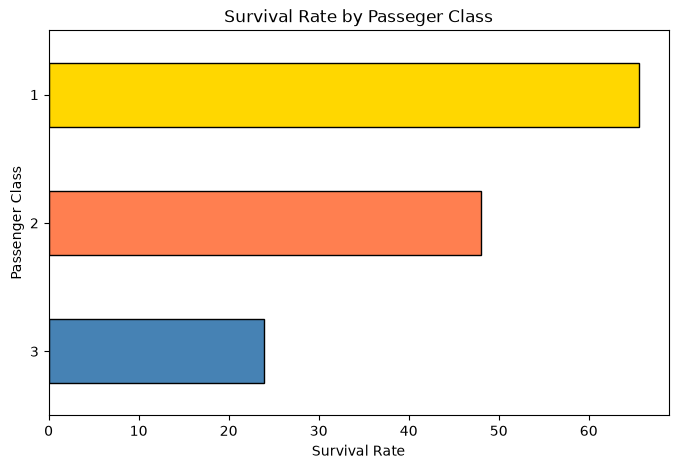

In [28]:
survival_by_class=df.groupby('Pclass')['Survived'].mean()*100
plt.figure(figsize=(8,5))
survival_by_class.sort_values().plot(kind='barh',color=['steelblue','coral','gold'],edgecolor='black')
plt.title('Survival Rate by Passeger Class')
plt.xlabel('Survival Rate')
plt.ylabel('Passenger Class')
plt.show()

In [34]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df[['Sex', 'Embarked', 'FamilySize', 'IsAlone']].head())

   Sex  Embarked  FamilySize  IsAlone
0    0       0.0           2        0
1    1       1.0           2        0
2    1       0.0           1        1
3    1       0.0           2        0
4    0       0.0           1        1


In [35]:
X=df[['Sex','Pclass','Age','Fare','FamilySize','IsAlone']]
y=df['Survived']

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression()

model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc1=accuracy_score(y_test,y_pred)
print("Accuracy Score for Logistic Regression Model:", acc1)



from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(random_state=42,max_depth=4)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc2=accuracy_score(y_test,y_pred)
print("Accuracy Score for Decision Tree model: ", acc2)



from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(random_state=42,n_estimators=100)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc3=accuracy_score(y_test,y_pred)
print("Accuracy Score for Random Forest model: ",acc3)


Accuracy Score for Logistic Regression Model: 0.7622377622377622
Accuracy Score for Decision Tree model:  0.7552447552447552
Accuracy Score for Random Forest model:  0.7902097902097902


In [40]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(model,X,y,cv=5)
print("Individual Fold Scores:",scores)
print("Mean accuracy:",scores.mean())
print("Standard Deviation:",scores.std())

Individual Fold Scores: [0.74825175 0.83216783 0.83216783 0.75524476 0.84507042]
Mean accuracy: 0.8025805180734757
Standard Deviation: 0.04182941540285436


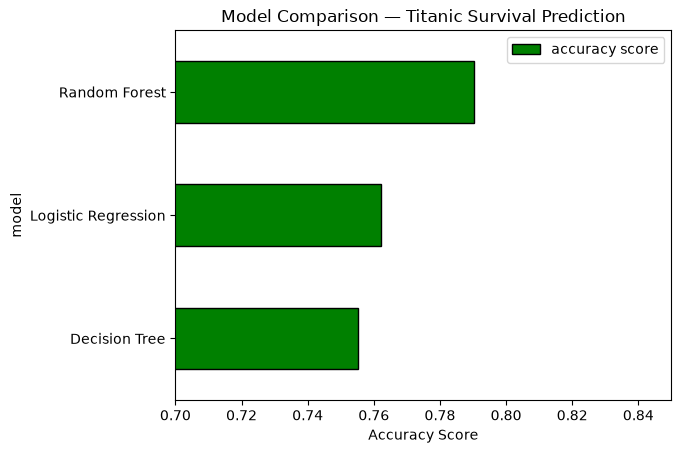

In [57]:
import matplotlib.pyplot as plt

accuracies={'model':['Logistic Regression','Decision Tree','Random Forest'],'accuracy score':[acc1,acc2,acc3]}
df=pd.DataFrame(accuracies)

df=df.set_index('model')

df.sort_values(by='accuracy score').plot(kind='barh',color='green',edgecolor='black')
plt.title("Model Comparison — Titanic Survival Prediction")
plt.xlabel('Accuracy Score')
plt.xlim(0.7, 0.85)
plt.show()